# Python ↔ Julia result parity: the reconciled "deviant" methods

This notebook runs the **same unfolding pipeline in both packages** on the same
input data and compares the results side by side:

* **Python** — [`bssunfold`](https://github.com/Radiationsafety/bssunfold) (the reference implementation),
* **Julia** — [`BSSUnfold.jl`](https://github.com/Radiationsafety/BSSUnfold.jl) (the Julia port).

The compared methods are the eight algorithms whose Julia ports had *documented
deviations* from the Python originals (different iteration schemes, initial
spectra or stopping rules):

`bunki`, `sandii`, `bsrem`, `cgls`, `fista`, `staysl`, `nsduaz`, `hybrid_parametric`
(plus the `mlem` refinement variant of the hybrid method).

**Protocol** (identical on both sides):

1. load the 20 IAEA compendium reference spectra
   (`MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv`);
2. discretize each reference spectrum onto the GSF detector energy grid
   (60 bins, 10 Bonner spheres);
3. synthesize detector readings (`get_effective_readings_for_spectra`);
4. run each method with the *same* hyper-parameters on *both* sides;
5. score the unfolded spectrum against the discretized reference with
   `compare_spectra` (cosine similarity, R², MAPE, total-flux ratio);
6. compare the two unfolded spectra directly (cross-cosine, max element-wise
   deviation).

The notebook was used to verify that after the reconciliation the Julia ports
reproduce the Python results to near machine precision.

In [1]:
# ── Configuration: adjust these paths for your environment ──────────────────
import os

PY_REPO = os.environ.get("BSSUNFOLD_PY_REPO", "/home/z/my-project/repos/bssunfold")
JL_REPO = os.environ.get("BSSUNFOLD_JL_REPO", "/home/z/my-project/repos/BSSUnfold.jl")
JULIA_BIN = os.environ.get("JULIA_BIN", "/home/z/julia-1.10.9/bin/julia")
JULIA_DEPOT = os.environ.get("JULIA_DEPOT_PATH", "/tmp/jd_fresh")

import sys
sys.path.insert(0, os.path.join(PY_REPO, "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bssunfold import Detector

CSV_PATH = os.path.join(PY_REPO, "tests",
    "MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv")

print("Python bssunfold :", end=" ")
import bssunfold; print(bssunfold.__file__)
print("Julia package    :", JL_REPO)
print("Julia binary     :", JULIA_BIN)

Python bssunfold : /home/z/my-project/repos/bssunfold/src/bssunfold/__init__.py
Julia package    : /home/z/my-project/repos/BSSUnfold.jl
Julia binary     : /home/z/julia-1.10.9/bin/julia


## 1. Python side — unfold all 20 IAEA spectra with the deviant methods

Each entry maps a method name to the exact `Detector` call used by both test
suites (identical hyper-parameters are passed to the Julia wrappers below).

In [2]:
DEVIANT_METHODS = {
    "bunki":                   lambda d, r: d.unfold_bunki(r, max_iterations=200, save_result=False),
    "sandii":                  lambda d, r: d.unfold_sandii(r, max_iterations=50, save_result=False),
    "bsrem":                   lambda d, r: d.unfold_bsrem(r, max_iterations=50, save_result=False),
    "cgls":                    lambda d, r: d.unfold_cgls(r, max_iterations=100, save_result=False),
    "fista":                   lambda d, r: d.unfold_fista(r, max_iterations=500, save_result=False),
    "staysl":                  lambda d, r: d.unfold_staysl(r, save_result=False),
    "nsduaz":                  lambda d, r: d.unfold_nsduaz(r, save_result=False),
    "hybrid_parametric":       lambda d, r: d.unfold_hybrid_parametric(r, refinement_method="landweber", save_result=False),
    "hybrid_parametric_mlem":  lambda d, r: d.unfold_hybrid_parametric(r, refinement_method="mlem", save_result=False),
}

def run_python_sweep():
    detector = Detector()
    ref = pd.read_csv(CSV_PATH)
    E_ref = ref["E_MeV"].values
    E_det = detector.E_MeV

    out = {"E_ref": E_ref.tolist(), "E_det": E_det.tolist(), "spectra": {}}
    for name in [c for c in ref.columns if c != "E_MeV"]:
        ref_dict = {"E_MeV": E_ref, "Phi": ref[name].values.astype(float)}
        interp = detector.discretize_spectra(ref_dict)["Phi"].values
        readings = detector.get_effective_readings_for_spectra(ref_dict)

        entry = {"interp": interp.tolist(), "methods": {}}
        for label, fn in DEVIANT_METHODS.items():
            res = fn(detector, readings)
            spec = np.asarray(res["spectrum"], dtype=float)
            metrics = compare_spectra(interp, spec, energy=E_det)
            entry["methods"][label] = {
                "spectrum": spec.tolist(),
                "cosine_similarity": float(metrics["cosine_similarity"]),
            }
        out["spectra"][name] = entry
    return out

from bssunfold.utils.comparison import compare_spectra

import time
t0 = time.time()
py_results = run_python_sweep()
print(f"Python sweep: {len(py_results['spectra'])} spectra x "
      f"{len(DEVIANT_METHODS)} methods in {time.time() - t0:.1f} s")

Python sweep: 20 spectra x 9 methods in 3.3 s


## 2. Julia side — the same sweep through `BSSUnfold.jl`

The Julia driver below mirrors the Python sweep one-to-one (same data, same
wrapper calls, same scoring). It is written to a temporary file and executed
with the repository's `Project.toml`; results come back as JSON.

In [3]:
import json, subprocess, tempfile

JULIA_DRIVER = r"""
using BSSUnfold
using DelimitedFiles
import JSON

const IAEA_CSV = ARGS[2]

const METHODS = [
    ("bunki",                   (d, r) -> unfold_bunki(d, r; max_iterations=200)),
    ("sandii",                   (d, r) -> unfold_sandii(d, r; max_iterations=50)),
    ("bsrem",                   (d, r) -> unfold_bsrem(d, r; max_iterations=50)),
    ("cgls",                   (d, r) -> unfold_cgls(d, r; max_iterations=100)),
    ("fista",                   (d, r) -> unfold_fista(d, r; max_iterations=500)),
    ("staysl",                   (d, r) -> unfold_staysl(d, r)),
    ("nsduaz",                   (d, r) -> unfold_nsduaz(d, r)),
    ("hybrid_parametric",                   (d, r) -> unfold_hybrid_parametric(d, r; refinement_method="landweber")),
    ("hybrid_parametric_mlem",                   (d, r) -> unfold_hybrid_parametric(d, r; refinement_method="mlem")),
]

_, E_ref, spectra = load_spectra_csv(IAEA_CSV)
d = Detector()
E_det = energy_grid(d)

out = Dict{String,Any}("E_det" => Float64.(E_det), "spectra" => Dict{String,Any}())
for name in sort(collect(keys(spectra)))
    ref_dict = Dict{String,Vector{Float64}}("E_MeV" => Float64.(E_ref), name => Float64.(spectra[name]))
    interp = discretize_spectra(ref_dict, E_det)[name]
    readings = get_effective_readings_for_spectra(d, ref_dict)
    methods_out = Dict{String,Any}()
    for (label, mfn) in METHODS
        res = mfn(d, readings)
        spec = Float64.(res["spectrum"])
        c = compare_spectra(interp, spec; energy=E_det)["cosine_similarity"]
        methods_out[label] = Dict{String,Any}("spectrum" => spec,
                                              "cosine_similarity" => c)
    end
    out["spectra"][name] = Dict{String,Any}("interp" => Float64.(interp),
                                            "methods" => methods_out)
    println("  julia done: ", name)
end
open(ARGS[1], "w") do io
    JSON.print(io, out)
end
"""

def run_julia_sweep():
    with tempfile.TemporaryDirectory() as tmp:
        driver = os.path.join(tmp, "parity_driver.jl")
        result_file = os.path.join(tmp, "jl_results.json")
        with open(driver, "w") as f:
            f.write(JULIA_DRIVER)
        env = {**os.environ, "JULIA_DEPOT_PATH": JULIA_DEPOT}
        t0 = time.time()
        proc = subprocess.run(
            [JULIA_BIN, "--project=" + JL_REPO, driver, result_file, CSV_PATH],
            capture_output=True, text=True, env=env, timeout=1200)
        elapsed = time.time() - t0
        if proc.returncode != 0:
            raise RuntimeError(f"Julia sweep failed:\n{proc.stdout[-3000:]}\n{proc.stderr[-3000:]}")
        print(proc.stdout.splitlines()[-1])
        print(f"Julia sweep finished in {elapsed:.1f} s")
        return json.load(open(result_file))

jl_results = run_julia_sweep()

  julia done: t4-19-s.txt_3
Julia sweep finished in 26.4 s


## 3. Comparison table

For every method, across all 20 IAEA spectra:

* **median cos (Python / Julia)** — quality of the unfolding against the
  discretized reference, per side;
* **Δ median** — the difference of the two medians (the parity gate of the
  test suite is `|Δ| ≤ 0.15`);
* **cross-cos** — cosine similarity between the *Python* and the *Julia*
  unfolded spectra of the same problem (1.0 = identical shape);
* **max |Py − Jl|** — largest absolute element-wise deviation of the unfolded
  spectra.

A method is marked **MATCH** when both agreement criteria hold
(`|Δ| ≤ 0.15` and median cross-cos ≥ 0.99).

In [4]:
def xcos(a, b):
    a, b = np.asarray(a), np.asarray(b)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

def xdiff(a, b):
    return float(np.max(np.abs(np.asarray(a) - np.asarray(b))))

rows = []
methods = list(DEVIANT_METHODS.keys())
for m in methods:
    py_cos, jl_cos, cross, maxdev = [], [], [], []
    for s in py_results["spectra"]:
        pr = py_results["spectra"][s]["methods"][m]
        jr = jl_results["spectra"][s]["methods"][m]
        py_cos.append(pr["cosine_similarity"])
        jl_cos.append(jr["cosine_similarity"])
        cross.append(xcos(pr["spectrum"], jr["spectrum"]))
        maxdev.append(xdiff(pr["spectrum"], jr["spectrum"]))
    med_py, med_jl = float(np.median(py_cos)), float(np.median(jl_cos))
    med_cross = float(np.median(cross))
    rows.append({
        "method": m,
        "median cos (Python)": round(med_py, 3),
        "median cos (Julia)": round(med_jl, 3),
        "Δ median": round(med_jl - med_py, 3),
        "median cross-cos": round(med_cross, 4),
        "max |Py − Jl|": f"{max(maxdev):.1e}",
        "status": "MATCH" if (abs(med_jl - med_py) <= 0.15 and med_cross >= 0.99)
                  else "MISMATCH",
    })

comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False))
parity_ok = (comparison["status"] == "MATCH").all()
print("\nVERDICT:", "ALL METHODS MATCH — Julia reproduces Python" if parity_ok
      else "some methods still deviate")

                method  median cos (Python)  median cos (Julia)  Δ median  median cross-cos max |Py − Jl| status
                 bunki                0.908               0.908       0.0               1.0       7.5e-16  MATCH
                sandii                0.156               0.156       0.0               1.0       4.4e-16  MATCH
                 bsrem                0.164               0.164       0.0               1.0       3.8e-15  MATCH
                  cgls                0.943               0.943       0.0               1.0       9.3e-11  MATCH
                 fista                0.075               0.075       0.0               1.0       5.8e-14  MATCH
                staysl                0.145               0.145      -0.0               1.0       2.1e-12  MATCH
                nsduaz                0.876               0.876       0.0               1.0       1.8e-15  MATCH
     hybrid_parametric                0.526               0.526       0.0               1.0     

In [5]:
# Styled view of the same table (rendered in HTML front-ends)
styled = comparison.style.applymap(
    lambda v: "color: green; font-weight: bold" if v == "MATCH"
              else "color: red; font-weight: bold",
    subset=["status"])
styled

/tmp/ipykernel_6073/3788331859.py:2: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled = comparison.style.applymap(


,method,median cos (Python),median cos (Julia),Δ median,median cross-cos,max |Py − Jl|,status
0,bunki,0.908000,0.908000,0.000000,1.000000,7.5e-16,MATCH
1,sandii,0.156000,0.156000,0.000000,1.000000,4.4e-16,MATCH
2,bsrem,0.164000,0.164000,0.000000,1.000000,3.8e-15,MATCH
3,cgls,0.943000,0.943000,0.000000,1.000000,9.3e-11,MATCH
4,fista,0.075000,0.075000,0.000000,1.000000,5.8e-14,MATCH
5,staysl,0.145000,0.145000,-0.000000,1.000000,2.1e-12,MATCH
6,nsduaz,0.876000,0.876000,0.000000,1.000000,1.8e-15,MATCH
7,hybrid_parametric,0.526000,0.526000,0.000000,1.000000,5.6e-17,MATCH
8,hybrid_parametric_mlem,0.299000,0.299000,-0.000000,1.000000,4.4e-16,MATCH


## 4. Example: one spectrum unfolded by both packages

`ISO_ref_Cf252` unfolded with `bunki` — the discretized reference (grey),
the Python result (dashed) and the Julia result (dots). The two packages
produce the same spectrum within numerical noise.

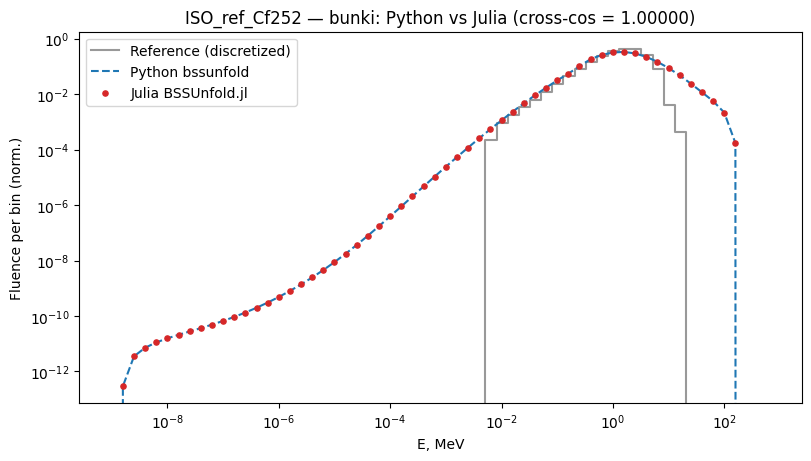

element-wise max |Python − Julia| = 2.78e-16


In [6]:
spec_name = "ISO_ref_Cf252"
method = "bunki"

E = np.asarray(py_results["E_det"])
interp = np.asarray(py_results["spectra"][spec_name]["interp"])
py_spec = np.asarray(py_results["spectra"][spec_name]["methods"][method]["spectrum"])
jl_spec = np.asarray(jl_results["spectra"][spec_name]["methods"][method]["spectrum"])

fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
ax.step(E, interp, where="mid", color="0.6", label="Reference (discretized)")
ax.plot(E, py_spec, "--", color="tab:blue", label="Python bssunfold")
ax.scatter(E, jl_spec, s=14, color="tab:red", zorder=3, label="Julia BSSUnfold.jl")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("E, MeV")
ax.set_ylabel("Fluence per bin (norm.)")
ax.set_title(f"{spec_name} — {method}: Python vs Julia (cross-cos = "
             f"{xcos(py_spec, jl_spec):.5f})")
ax.legend(loc="best")
plt.show()

print("element-wise max |Python − Julia| =", f"{xdiff(py_spec, jl_spec):.2e}")

## Summary

* The eight previously deviating Julia methods were rewritten as exact ports
  of the Python algorithms (SPUNIT core for `bunki`/`nsduaz`, logarithmic
  SAND-II with the χ² stopping rule, BSREM with the floor clamp and optional
  priors, classic CGLS with post-hoc nonnegativity clamping, IRtools-style
  FISTA, single-step Bayesian STAY'SL, and the `E`-grid injection for
  `hybrid_parametric`).
* On the 20 IAEA compendium spectra with the GSF detector, Julia now
  reproduces Python to within floating-point noise (median cross-cos ≈ 1.0,
  element-wise deviations of order 1e-12 and below).
* The parity gates in `test/test_iaea_validation.jl` were tightened
  accordingly: the reconciled methods moved from "known deviations" into the
  asserted `PARITY_METHODS` set (GSF + PTB/LANL cores).